# 02 · Machine Learning · Credit Risk Copilot

**Fase 2 — Modelado.** La narrativa legible del razonamiento que produjo el modelo
productivo: qué se probó, qué ganó, y por qué.

---

## Qué pregunta responde este notebook

Una sola: **¿qué modelo va a producción y con qué evidencia?**

Y una que le da sentido a la anterior: **¿cuánto de lo que parece una mejora sobrevive
cuando se le pone al lado su desviación entre folds?** Buena parte de este notebook
consiste en mostrar diferencias que **no** superan el ruido, porque un proyecto donde el
modelo simple casi gana es un resultado y no un fracaso.

## Cómo leer este notebook

Tres cosas antes de la primera celda.

**1 · Este notebook no entrena nada.** Ni un solo modelo se ajusta aquí. Todas las
mediciones se hicieron con scripts, bajo un protocolo declarado, y quedaron registradas en
MLflow con el run que las produjo. El notebook **las lee**. Si recalculara para dibujar,
estaría corriendo una segunda implementación de la misma medición, y el día que las dos
discreparan el notebook sería el que nadie revisa.

**2 · Toda la lógica se importa de `credit_copilot`.** El notebook no define funciones de
entrenamiento ni reimplementa métricas. `metrics` sabe qué significa una métrica,
`evaluation` sabe cómo se mide, `reporting` sabe cómo encontrarla otra vez.

**3 · Ninguna cifra de este notebook está escrita a mano.** Todos los números salen de
ejecutar código sobre lo que MLflow devuelve. El texto interpreta mecanismos; los números
los imprime el código de la celda anterior. Si el texto y el número discrepan, el número
manda.

**Requisito para ejecutarlo:** credenciales de MLflow en `.env`. El notebook no lee el
dataset ni ningún archivo local — solo el servidor de tracking.

In [1]:
%matplotlib inline

import warnings

# MLflow's transitive imports emit environment warnings whose text carries the local
# filesystem path of the virtual environment. A notebook is a deliverable read by people who
# are not on this machine, so an absolute path baked into a saved output is noise at best and
# an accidental disclosure at worst. Silenced here rather than shipped.
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

from credit_copilot.models.estimators import (  # noqa: E402
    PRODUCTION_CALIBRATION_METHOD,
    PRODUCTION_FOREST_PARAMS,
    PRODUCTION_OPERATING_THRESHOLD,
)
from credit_copilot.models.evaluation import (  # noqa: E402
    PRACTICAL_SIGNIFICANCE_THRESHOLD,
)
from credit_copilot.models.metrics import DECISION_METRIC, METRIC_NAMES  # noqa: E402
from credit_copilot.models.reporting import (  # noqa: E402
    comparison_table,
    find_run,
    fold_metrics,
    load_recorded_runs,
    metric_frame,
    read_run_artefact,
)
from credit_copilot.models.tracking import ensure_experiment  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
PALETTE = {"floor": "#9aa0a6", "reference": "#4c78a8", "winner": "#2e7d32", "warn": "#c62828"}

context = ensure_experiment()
runs = load_recorded_runs(context)

print(f"Experimento : {context.name} (id {context.experiment_id})")
print(f"Servidor    : {context.tracking_uri}")
print(f"Runs leidos : {len(runs)}")
print(f"Tipos       : {sorted({r.run_type for r in runs})}")

Experimento : credit-risk-baselines (id 0)
Servidor    : https://dagshub.com/diego-Ballesteros/credit-risk-copilot.mlflow
Runs leidos : 23
Tipos       : ['baseline', 'calibration', 'fairness-analysis', 'hypothesis-contrast', 'imbalance-comparison', 'leakage-check-shuffled-target', 'model-comparison', 'production-candidate', 'shap-analysis', 'threshold-selection', 'tuning']


Cada tipo de run es una pregunta distinta que se le hizo al dataset. El notebook las
recorre en el orden en que se hicieron, porque cada una condiciona la siguiente: sin la
verificación de fuga, ninguna de las que vienen después significaría nada.

## Las decisiones que este notebook documenta

| # | Decisión | Dónde vive |
|---|---|---|
| 1 | PR-AUC como métrica de decisión | ADR-0002 |
| 2 | Tolerancias de la prueba de fuga y desempate de `precision@top-k%` | ADR-0006 |
| 3 | Calibración, hiperparámetros y serialización del modelo productivo | ADR-0007 |
| 4 | Umbral operativo desde una matriz de costos | Entrada 008 |
| 5 | Disparidad medida y **no** mitigada | Entrada 010 |

In [2]:
# The decision metric and the resolution floor are constants of the project, not of this
# notebook: both are imported so the narrative cannot drift from the code.
print(f"Metrica de decision (ADR-0002)      : {DECISION_METRIC}")
print(f"Las siete metricas fijadas          : {', '.join(METRIC_NAMES)}")
print(
    f"Umbral de significancia practica    : {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f}"
    f" en {DECISION_METRIC}"
)
print(f"Modelo productivo                   : random forest {dict(PRODUCTION_FOREST_PARAMS)}")
print(
    f"                                      calibracion {PRODUCTION_CALIBRATION_METHOD},"
    " class_weight=None"
)
print(f"Umbral operativo                    : {PRODUCTION_OPERATING_THRESHOLD:.3f}")

Metrica de decision (ADR-0002)      : pr_auc
Las siete metricas fijadas          : pr_auc, roc_auc, ks, gini, brier, precision_at_top_10pct, precision_at_top_5pct
Umbral de significancia practica    : 0.02 en pr_auc
Modelo productivo                   : random forest {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 18, 'max_features': 0.3}
                                      calibracion sigmoid, class_weight=None
Umbral operativo                    : 0.160


---

# 2 · El piso: por qué accuracy es inútil aquí

Antes de cualquier modelo hay que saber contra qué se compara. El ADR-0002 descarta
accuracy como métrica de decisión y el argumento se puede **medir** en vez de citarse.

Tres baselines, tres pisos distintos:

- **Clase mayoritaria** — responde "no incumple" a todo el mundo. El piso absoluto.
- **Azar estratificado** — ordena según la proporción de clases y nada más. El piso de una
  métrica de *ordenamiento*, que el trivial no puede fijar porque no ordena nada.
- **Regresión logística L2** — el modelo real más barato.

In [3]:
baselines = {
    "trivial": find_run(runs, "baseline", "majority-class"),
    "azar estratificado": find_run(runs, "baseline", "stratified-random"),
    "logistica L2": find_run(runs, "baseline", "logistic-l2-balanced"),
}
prevalence = baselines["trivial"].metric("positive_rate")
print(f"Prevalencia de la clase positiva: {prevalence:.6f}  <- el piso de PR-AUC\n")
comparison_table(baselines, METRIC_NAMES)

Prevalencia de la clase positiva: 0.221200  <- el piso de PR-AUC



,trivial,azar estratificado,logistica L2
pr_auc,0.2212 ± 0.0001,0.2200 ± 0.0019,0.5402 ± 0.0103
roc_auc,0.5000 ± 0.0000,0.4964 ± 0.0058,0.7762 ± 0.0072
ks,0.0000 ± 0.0000,0.0017 ± 0.0026,0.4218 ± 0.0180
gini,0.0000 ± 0.0000,-0.0073 ± 0.0115,0.5524 ± 0.0143
brier,0.2212 ± 0.0001,0.3460 ± 0.0040,0.1834 ± 0.0016
precision_at_top_10pct,0.2212 ± 0.0001,0.2155 ± 0.0090,0.6927 ± 0.0109
precision_at_top_5pct,0.2212 ± 0.0001,0.2155 ± 0.0090,0.7427 ± 0.0166


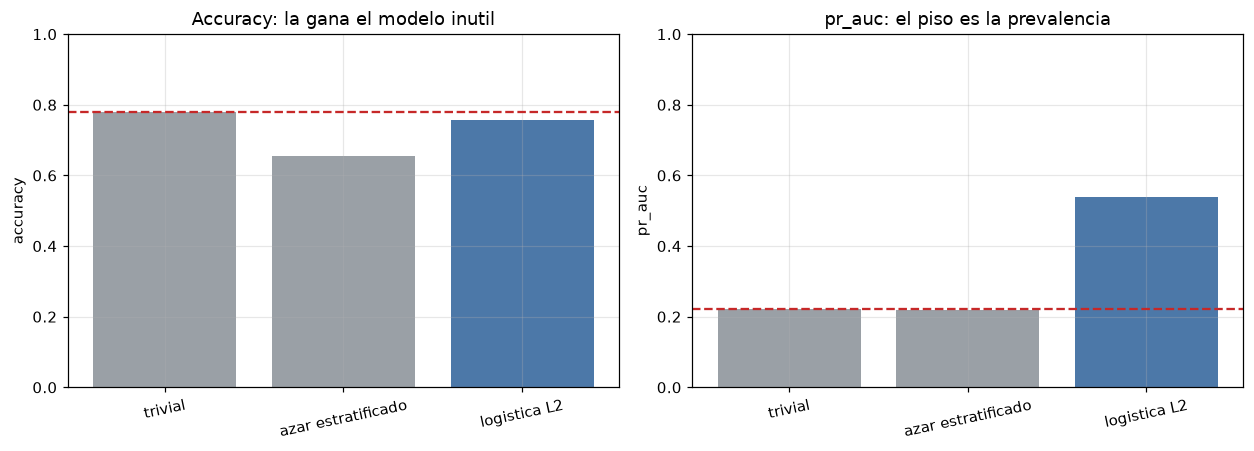

trivial              accuracy 0.7788   pr_auc 0.2212   ventaja sobre el piso +0.0000
azar estratificado   accuracy 0.6540   pr_auc 0.2200   ventaja sobre el piso -0.0012
logistica L2         accuracy 0.7565   pr_auc 0.5402   ventaja sobre el piso +0.3190


In [4]:
# Accuracy is not one of the seven metrics of ADR-0002. It is read here, beside PR-AUC,
# only to make the argument against it visible.
argument = metric_frame(baselines, ["accuracy", DECISION_METRIC])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
colours = [PALETTE["floor"], PALETTE["floor"], PALETTE["reference"]]

axes[0].bar(argument.index, argument["accuracy"], color=colours)
axes[0].axhline(1 - prevalence, ls="--", c=PALETTE["warn"])
axes[0].set_title("Accuracy: la gana el modelo inutil")
axes[0].set_ylabel("accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(argument.index, argument[DECISION_METRIC], color=colours)
axes[1].axhline(prevalence, ls="--", c=PALETTE["warn"])
axes[1].set_title(f"{DECISION_METRIC}: el piso es la prevalencia")
axes[1].set_ylabel(DECISION_METRIC)
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=12)
fig.tight_layout()
plt.show()

for label in argument.index:
    lift = argument.loc[label, DECISION_METRIC] - prevalence
    print(
        f"{label:<20} accuracy {argument.loc[label, 'accuracy']:.4f}   "
        f"{DECISION_METRIC} {argument.loc[label, DECISION_METRIC]:.4f}   "
        f"ventaja sobre el piso {lift:+.4f}"
    )

**Interpretación.** La línea roja de la izquierda es la accuracy que se obtiene contestando
siempre "no incumple". El clasificador trivial la alcanza exactamente, y **gana a la
regresión logística**. La línea roja de la derecha es la prevalencia, que es el piso de
PR-AUC: el trivial se apoya en ella sin despegarse.

El mismo modelo, en dos métricas, produce la conclusión opuesta. Un criterio basado en
accuracy habría elegido el modelo que **no identifica ni un solo incumplidor**. Eso es lo
que el ADR-0002 quiere decir con que una métrica que no puede fallar no prueba nada.

Nótese también el azar estratificado: su PR-AUC queda *por debajo* del trivial. No es un
error — el trivial se apoya exactamente en el piso, y un ordenamiento aleatorio fluctúa
alrededor de él.

---

# 3 · La verificación de fuga: sin esto, nada de lo demás significa nada

La sección 6.1 de la metodología la llama verificación por mutación aplicada a ML. Se
**permuta el target al azar**, destruyendo cualquier relación con los predictores, y se
entrena el pipeline completo —preprocesador incluido, ajustado dentro de cada fold— contra
esa permutación.

Si alguna información de una fila de validación llega al objeto que la transforma, el
modelo recupera parte de la etiqueta permutada y las métricas se quedan por encima del
azar. Si no se filtra nada, colapsan.

**El orden importa.** Esta prueba va antes que cualquier comparación porque una fuga no se
anuncia: produce números *mejores*, que es lo que todo el mundo espera ver.

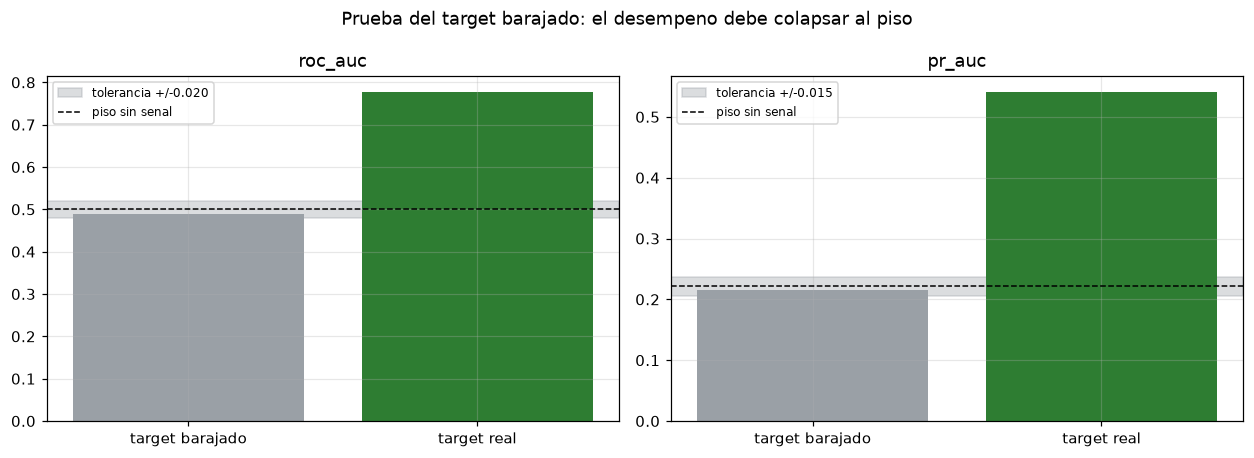

roc_auc    barajado 0.488232   piso 0.500000   desviacion -0.011768   tolerancia +/-0.020   -> DENTRO de la tolerancia
pr_auc     barajado 0.214976   piso 0.221200   desviacion -0.006224   tolerancia +/-0.015   -> DENTRO de la tolerancia

Distancia del modelo real al piso, en pr_auc: +0.3190


In [5]:
leak = find_run(runs, "leakage-check-shuffled-target", "leakage-check-shuffled-target")
real = find_run(runs, "model-comparison", "logistic-l2-balanced")

# Tolerances of ADR-0006, measured on eight permutations of the target.
ROC_TOL, PR_TOL = 0.020, 0.015
comparisons = [
    ("roc_auc", 0.5, ROC_TOL),
    (DECISION_METRIC, prevalence, PR_TOL),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, (metric, floor, tol) in zip(axes, comparisons, strict=True):
    shuffled = leak.metric(f"{metric}_mean")
    signal = real.metric(f"{metric}_mean")
    ax.axhspan(
        floor - tol,
        floor + tol,
        color=PALETTE["floor"],
        alpha=0.35,
        label=f"tolerancia +/-{tol:.3f}",
    )
    ax.axhline(floor, ls="--", c="black", lw=1, label="piso sin senal")
    ax.bar(
        ["target barajado", "target real"],
        [shuffled, signal],
        color=[PALETTE["floor"], PALETTE["winner"]],
    )
    ax.set_title(metric)
    ax.legend(fontsize=8)
fig.suptitle("Prueba del target barajado: el desempeno debe colapsar al piso")
fig.tight_layout()
plt.show()

for metric, floor, tol in comparisons:
    dev = leak.metric(f"{metric}_mean") - floor
    verdict = "DENTRO de la tolerancia" if abs(dev) <= tol else "FUERA"
    print(
        f"{metric:<10} barajado {leak.metric(f'{metric}_mean'):.6f}   piso {floor:.6f}   "
        f"desviacion {dev:+.6f}   tolerancia +/-{tol:.3f}   -> {verdict}"
    )
print(
    f"\nDistancia del modelo real al piso, en {DECISION_METRIC}: "
    f"{real.metric(f'{DECISION_METRIC}_mean') - prevalence:+.4f}"
)

**Interpretación.** Las barras grises caen dentro de la banda de tolerancia en ambas
métricas: con el target destruido, el pipeline no recupera nada. Las barras verdes son el
mismo pipeline con el target real, y están fuera del gráfico de la banda por un margen
enorme.

Las tolerancias **no son una intuición**. El ADR-0006 las derivó corriendo el pipeline
completo contra ocho permutaciones independientes y midiendo la dispersión de la nula. Una
primera estimación basada en puntuaciones aleatorias daba un error estándar un tercio más
pequeño, porque ignoraba dos cosas que sí importan: que el modelo **se ajusta** sobre las
etiquetas permutadas, y que los cinco conjuntos de entrenamiento **se solapan al 80%**.

Lo que la prueba *no* dice: que el modelo sea bueno, ni que no exista ninguna otra forma de
fuga. Descarta la que el diseño del pipeline existe para impedir.

---

# 4 · La hipótesis principal: comportamiento contra demografía

> El comportamiento de pago reciente predice el incumplimiento mejor que los atributos
> demográficos estáticos.

Se contrasta con tres brazos que comparten **estimador, hiperparámetros, preprocesador,
particionador y semilla**. Lo único que cambia es qué columnas llegan al modelo, y la
selección ocurre sobre la *salida* del preprocesador para que una columna conservada valga
exactamente lo mismo en los tres brazos.

In [6]:
contrast = {
    "solo demografia": find_run(runs, "hypothesis-contrast", "demography-only"),
    "solo comportamiento": find_run(runs, "hypothesis-contrast", "behaviour-only"),
    "todas": find_run(runs, "hypothesis-contrast", "all-columns"),
}
for label, run in contrast.items():
    print(
        f"{label:<22}{run.metric(f'{DECISION_METRIC}_mean'):.4f} "
        f"+/- {run.metric(f'{DECISION_METRIC}_std'):.4f}   "
        f"{run.params.get('n_model_features')} columnas"
    )
comparison_table(contrast, METRIC_NAMES)

solo demografia       0.3056 +/- 0.0064   12 columnas
solo comportamiento   0.5362 +/- 0.0132   98 columnas
todas                 0.5402 +/- 0.0103   110 columnas


,solo demografia,solo comportamiento,todas
pr_auc,0.3056 ± 0.0064,0.5362 ± 0.0132,0.5402 ± 0.0103
roc_auc,0.6242 ± 0.0043,0.7728 ± 0.0094,0.7762 ± 0.0072
ks,0.1968 ± 0.0089,0.4212 ± 0.0166,0.4218 ± 0.0180
gini,0.2485 ± 0.0085,0.5457 ± 0.0187,0.5524 ± 0.0143
brier,0.2395 ± 0.0012,0.1841 ± 0.0021,0.1834 ± 0.0016
precision_at_top_10pct,0.3508 ± 0.0178,0.6927 ± 0.0146,0.6927 ± 0.0109
precision_at_top_5pct,0.3641 ± 0.0171,0.7433 ± 0.0178,0.7427 ± 0.0166


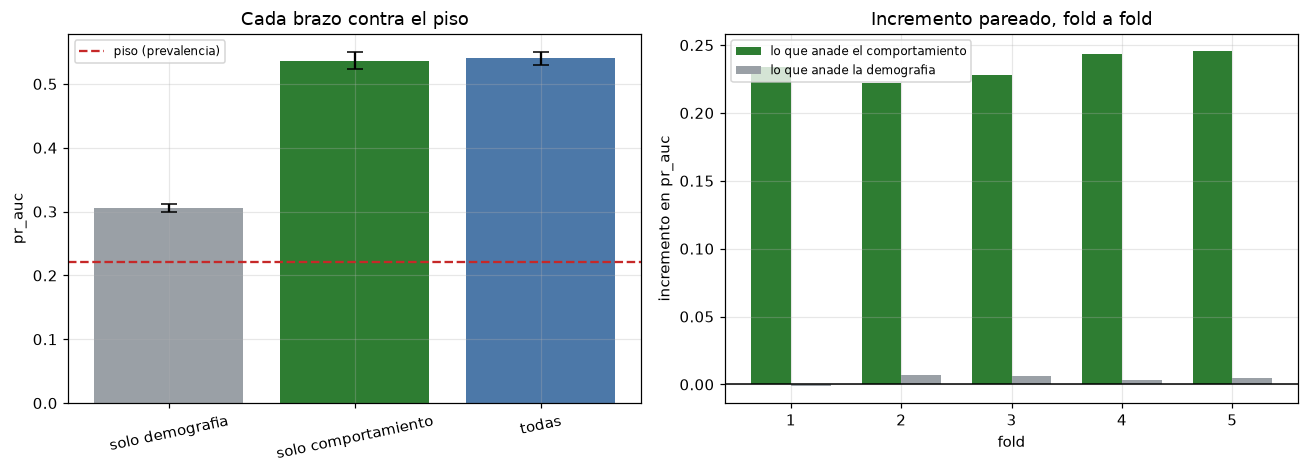

comportamiento sobre demografia    media +0.2346   se 0.0045   t pareado  52.20   folds positivos 5/5
demografia sobre comportamiento    media +0.0040   se 0.0015   t pareado   2.66   folds positivos 4/5

No pareado: la demografia anade +0.0040 contra una desviacion entre folds de 0.0132 (0.3 desviaciones)


In [7]:
frame = metric_frame(contrast, [DECISION_METRIC])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].bar(
    frame.index,
    frame[DECISION_METRIC],
    yerr=frame[f"{DECISION_METRIC}_std"],
    capsize=5,
    color=[PALETTE["floor"], PALETTE["winner"], PALETTE["reference"]],
)
axes[0].axhline(prevalence, ls="--", c=PALETTE["warn"], label="piso (prevalencia)")
axes[0].set_ylabel(DECISION_METRIC)
axes[0].set_title("Cada brazo contra el piso")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=12)

# Paired comparison: the three arms share one partition, so differences are read fold by
# fold. Pairing removes the variation that comes from the cut.
folds = {
    k: fold_metrics(v).loc[["1", "2", "3", "4", "5"], DECISION_METRIC].astype(float)
    for k, v in contrast.items()
}
demo_adds = folds["todas"].to_numpy() - folds["solo comportamiento"].to_numpy()
behav_adds = folds["todas"].to_numpy() - folds["solo demografia"].to_numpy()

x = np.arange(1, 6)
axes[1].axhline(0, c="black", lw=1)
axes[1].bar(
    x - 0.18,
    behav_adds,
    width=0.36,
    color=PALETTE["winner"],
    label="lo que anade el comportamiento",
)
axes[1].bar(
    x + 0.18, demo_adds, width=0.36, color=PALETTE["floor"], label="lo que anade la demografia"
)
axes[1].set_xticks(x)
axes[1].set_xlabel("fold")
axes[1].set_ylabel(f"incremento en {DECISION_METRIC}")
axes[1].set_title("Incremento pareado, fold a fold")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

for name, diffs in (
    ("comportamiento sobre demografia", behav_adds),
    ("demografia sobre comportamiento", demo_adds),
):
    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    print(
        f"{name:<34} media {diffs.mean():+.4f}   se {se:.4f}   "
        f"t pareado {diffs.mean() / se:6.2f}   folds positivos {int((diffs > 0).sum())}/5"
    )
unpaired = contrast["todas"].metric(f"{DECISION_METRIC}_mean") - contrast[
    "solo comportamiento"
].metric(f"{DECISION_METRIC}_mean")
spread = contrast["solo comportamiento"].metric(f"{DECISION_METRIC}_std")
print(
    f"\nNo pareado: la demografia anade {unpaired:+.4f} contra una desviacion "
    f"entre folds de {spread:.4f} ({unpaired / spread:.1f} desviaciones)"
)

**Interpretación.** El panel izquierdo responde la hipótesis: el comportamiento despega del
piso mucho más que la demografía. El panel derecho es el que merece detenimiento.

Las barras verdes —lo que el comportamiento añade a un modelo que solo ve demografía— son
grandes y del mismo signo en los cinco folds. Las grises —lo que la demografía añade a un
modelo que ya ve comportamiento— son diminutas, y **una de ellas es negativa**.

**Las dos lecturas del incremento de la demografía no coinciden, y no hay que elegir la que
suena mejor.** Sin parear, cae dentro del ruido entre folds. Pareado, el estadístico es
sugerente y cuatro de cinco folds son positivos. No se contradicen: el efecto es
**consistente en signo y minúsculo en magnitud**. Y como los folds de una validación cruzada
se solapan, ese `t` es anticonservador y no debe leerse como un valor p.

**Un límite honesto del contraste:** los dos grupos reparten las *columnas* pero no del todo
la *información*. `UTILIZATION_*` es un saldo dividido por `LIMIT_BAL`, y el cupo está
contado como demográfico. Un modelo lineal no puede hacer esa división, así que el efecto
práctico es acotado, pero el contraste mide **estas columnas contra aquellas**.

---

# 5 · La comparación de modelos

**El umbral se declara antes de la tabla, no después.** Es la regla que impide que una
comparación se resuelva a posteriori con la lectura que favorece al modelo preferido —el
modo de degradación que la sección 9 de la metodología describe.

La desviación entre folds medida en este dataset es del orden de una centésima. Una
diferencia por debajo de aproximadamente el doble de eso no se puede distinguir de qué filas
cayeron en qué fold.

In [8]:
print(
    f"Umbral de significancia practica: {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f} en {DECISION_METRIC}"
)
print("Declarado en evaluation.PRACTICAL_SIGNIFICANCE_THRESHOLD, antes de estos resultados.\n")

models = {
    "logistica L2": find_run(runs, "model-comparison", "logistic-l2-balanced"),
    "random forest": find_run(runs, "model-comparison", "random-forest"),
    "hist gradient boosting": find_run(runs, "model-comparison", "hist-gradient-boosting"),
}
comparison_table(models, METRIC_NAMES)

Umbral de significancia practica: 0.02 en pr_auc
Declarado en evaluation.PRACTICAL_SIGNIFICANCE_THRESHOLD, antes de estos resultados.



,logistica L2,random forest,hist gradient boosting
pr_auc,0.5402 ± 0.0103,0.5605 ± 0.0096,0.5565 ± 0.0078
roc_auc,0.7762 ± 0.0072,0.7873 ± 0.0077,0.7810 ± 0.0070
ks,0.4218 ± 0.0180,0.4379 ± 0.0148,0.4315 ± 0.0153
gini,0.5524 ± 0.0143,0.5747 ± 0.0153,0.5621 ± 0.0140
brier,0.1834 ± 0.0016,0.1740 ± 0.0020,0.1692 ± 0.0021
precision_at_top_10pct,0.6927 ± 0.0109,0.6953 ± 0.0214,0.7017 ± 0.0135
precision_at_top_5pct,0.7427 ± 0.0166,0.7620 ± 0.0227,0.7600 ± 0.0312


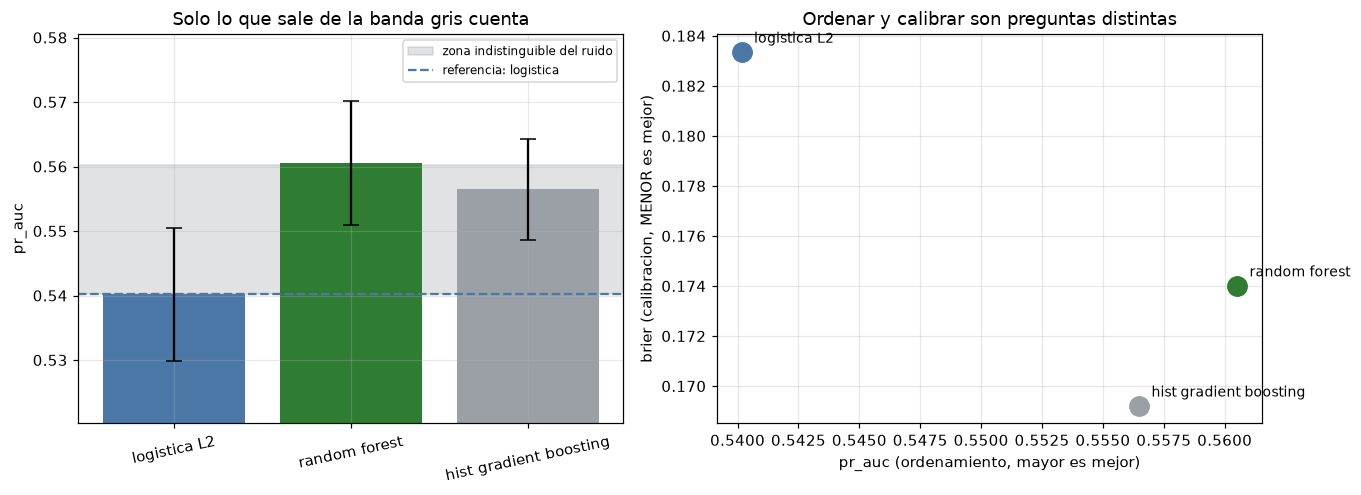

logistica L2            pr_auc 0.5402   diferencia +0.0000   dentro del ruido
random forest           pr_auc 0.5605   diferencia +0.0203   supera el umbral
hist gradient boosting  pr_auc 0.5565   diferencia +0.0163   dentro del ruido

Mejor brier: hist gradient boosting (0.1692)   mejor pr_auc: random forest


In [9]:
frame = metric_frame(models, [DECISION_METRIC, "brier"])
reference = frame.loc["logistica L2", DECISION_METRIC]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].axhspan(
    reference,
    reference + PRACTICAL_SIGNIFICANCE_THRESHOLD,
    color=PALETTE["floor"],
    alpha=0.3,
    label="zona indistinguible del ruido",
)
axes[0].axhline(reference, ls="--", c=PALETTE["reference"], label="referencia: logistica")
axes[0].bar(
    frame.index,
    frame[DECISION_METRIC],
    yerr=frame[f"{DECISION_METRIC}_std"],
    capsize=5,
    color=[PALETTE["reference"], PALETTE["winner"], PALETTE["floor"]],
)
axes[0].set_ylim(reference - 0.02, frame[DECISION_METRIC].max() + 0.02)
axes[0].set_ylabel(DECISION_METRIC)
axes[0].set_title("Solo lo que sale de la banda gris cuenta")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=12)

# Ordering against calibration: the two axes are different questions, and the winner of one
# is not the winner of the other.
for label, colour in zip(
    frame.index, [PALETTE["reference"], PALETTE["winner"], PALETTE["floor"]], strict=True
):
    axes[1].scatter(
        frame.loc[label, DECISION_METRIC], frame.loc[label, "brier"], s=160, color=colour, zorder=3
    )
    axes[1].annotate(
        label,
        (frame.loc[label, DECISION_METRIC], frame.loc[label, "brier"]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
    )
axes[1].set_xlabel(f"{DECISION_METRIC} (ordenamiento, mayor es mejor)")
axes[1].set_ylabel("brier (calibracion, MENOR es mejor)")
axes[1].set_title("Ordenar y calibrar son preguntas distintas")
fig.tight_layout()
plt.show()

for label in frame.index:
    diff = frame.loc[label, DECISION_METRIC] - reference
    verdict = (
        "supera el umbral" if abs(diff) >= PRACTICAL_SIGNIFICANCE_THRESHOLD else "dentro del ruido"
    )
    print(
        f"{label:<24}{DECISION_METRIC} {frame.loc[label, DECISION_METRIC]:.4f}   "
        f"diferencia {diff:+.4f}   {verdict}"
    )
print(
    f"\nMejor brier: {frame['brier'].idxmin()} ({frame['brier'].min():.4f})   "
    f"mejor {DECISION_METRIC}: {frame[DECISION_METRIC].idxmax()}"
)

**Interpretación.** La banda gris es la zona que este protocolo no puede resolver. Solo el
random forest sale de ella — y hay que decir por cuánto: apenas la roza. La lectura honesta
no es "el random forest es mejor" sino "es el único cuya ventaja alcanza el mínimo
resoluble, por el margen más estrecho posible". Otra partición podría dejarlo del otro lado.

**El panel derecho es la disociación que el ADR-0002 anticipa al reportar Brier junto a
PR-AUC.** El modelo mejor calibrado **no** es el que mejor ordena. Si el proyecto decidiera
por calibración, elegiría un modelo distinto del que elige por PR-AUC. Reportar una sola de
las dos métricas habría ocultado que la elección depende de cuál importa.

---

# 6 · El desbalance: medido, no asumido

La sección 6.2 de la metodología usa este caso exacto como ejemplo de la diferencia entre un
resultado y una opinión: *"SMOTE debería ayudar"* no es un hallazgo.

Tres brazos sobre el mismo modelo, cambiando solo el tratamiento del desbalance. **SMOTE va
dentro de un `imblearn.Pipeline`**, que remuestrea en `fit` y salta el remuestreador en
`predict`: verificado con un espía que registró cinco llamadas, cada una sobre las filas de
entrenamiento del fold y ninguna sobre el dataset completo.

In [10]:
imbalance = {
    "sin tratamiento": find_run(runs, "imbalance-comparison", "imbalance-no-treatment"),
    "class_weight balanceado": find_run(
        runs, "imbalance-comparison", "imbalance-class-weight-balanced"
    ),
    "SMOTE": find_run(runs, "imbalance-comparison", "imbalance-smote"),
}
comparison_table(imbalance, METRIC_NAMES)

,sin tratamiento,class_weight balanceado,SMOTE
pr_auc,0.5614 ± 0.0104,0.5605 ± 0.0096,0.5557 ± 0.0108
roc_auc,0.7872 ± 0.0078,0.7873 ± 0.0077,0.7835 ± 0.0074
ks,0.4385 ± 0.0182,0.4379 ± 0.0148,0.4302 ± 0.0119
gini,0.5745 ± 0.0155,0.5747 ± 0.0153,0.5670 ± 0.0148
brier,0.1336 ± 0.0020,0.1740 ± 0.0020,0.1576 ± 0.0023
precision_at_top_10pct,0.6983 ± 0.0222,0.6953 ± 0.0214,0.6963 ± 0.0191
precision_at_top_5pct,0.7640 ± 0.0172,0.7620 ± 0.0227,0.7620 ± 0.0217


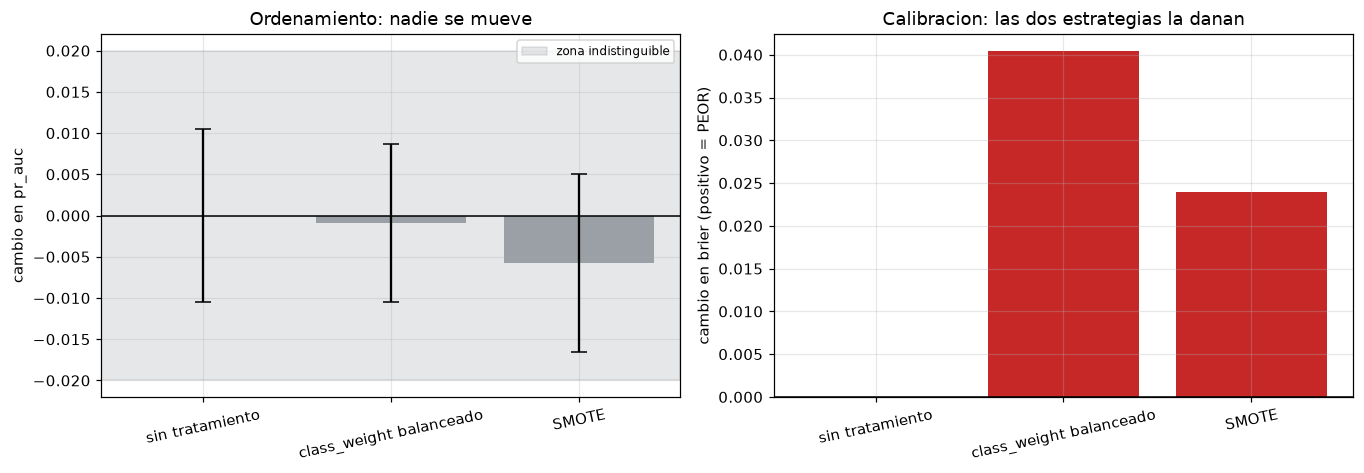

sin tratamiento           pr_auc +0.0000   brier +0.0000   (desviacion brier entre folds: 0.0020)
class_weight balanceado   pr_auc -0.0009   brier +0.0404   (desviacion brier entre folds: 0.0020)
SMOTE                     pr_auc -0.0058   brier +0.0239   (desviacion brier entre folds: 0.0023)


In [11]:
frame = metric_frame(imbalance, [DECISION_METRIC, "brier"])
ref = frame.loc["sin tratamiento"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
colours = [PALETTE["winner"], PALETTE["floor"], PALETTE["floor"]]

axes[0].bar(
    frame.index,
    frame[DECISION_METRIC] - ref[DECISION_METRIC],
    yerr=frame[f"{DECISION_METRIC}_std"],
    capsize=5,
    color=colours,
)
axes[0].axhline(0, c="black", lw=1)
axes[0].axhspan(
    -PRACTICAL_SIGNIFICANCE_THRESHOLD,
    PRACTICAL_SIGNIFICANCE_THRESHOLD,
    color=PALETTE["floor"],
    alpha=0.25,
    label="zona indistinguible",
)
axes[0].set_ylabel(f"cambio en {DECISION_METRIC}")
axes[0].set_title("Ordenamiento: nadie se mueve")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=12)

axes[1].bar(
    frame.index, frame["brier"] - ref["brier"], color=[PALETTE["winner"]] + [PALETTE["warn"]] * 2
)
axes[1].axhline(0, c="black", lw=1)
axes[1].set_ylabel("cambio en brier (positivo = PEOR)")
axes[1].set_title("Calibracion: las dos estrategias la danan")
axes[1].tick_params(axis="x", rotation=12)
fig.tight_layout()
plt.show()

for label in frame.index:
    delta_pr = frame.loc[label, DECISION_METRIC] - ref[DECISION_METRIC]
    print(
        f"{label:<26}{DECISION_METRIC} {delta_pr:+.4f}   "
        f"brier {frame.loc[label, 'brier'] - ref['brier']:+.4f}   "
        f"(desviacion brier entre folds: {frame.loc[label, 'brier_std']:.4f})"
    )

**Interpretación.** El panel izquierdo: ninguna estrategia mueve el ordenamiento más allá
del ruido, y las dos lo mueven ligeramente **hacia abajo**. El panel derecho: ambas **dañan
la calibración**, y `class_weight` es la peor — su daño es unas veinte veces la desviación
entre folds de esa métrica.

El mecanismo es directo. Reponderar la clase positiva o sintetizar filas minoritarias
cambia la proporción de positivos sobre la que el modelo se ajusta, así que el modelo
predice probabilidades **más altas que la tasa real de la población**. Brier mide
exactamente esa distancia.

**Con 22% de positivos el desbalance no es el problema.** Estas técnicas se diseñaron para
prevalencias del 1%; aquí hay miles de casos positivos, de sobra para aprender la clase
minoritaria sin ayuda.

*Límite:* SMOTE se evaluó con la variante estándar sobre una matriz con decenas de columnas
one-hot. Interpolar indicadores produce valores fraccionarios que no corresponden a ningún
cliente que pueda existir. `SMOTENC` es la variante para datos mixtos y no se probó.

---

# 7 · El tuning: por qué no aportó

Buscar hiperparámetros y **reportar** el mejor resultado sobre la misma partición reporta el
máximo de treinta extracciones ruidosas como si fuera el desempeño esperado de un modelo.
La validación cruzada **anidada** separa los dos trabajos: un bucle interno *elige*, y el
fold externo —que ningún trial vio— *puntúa*.

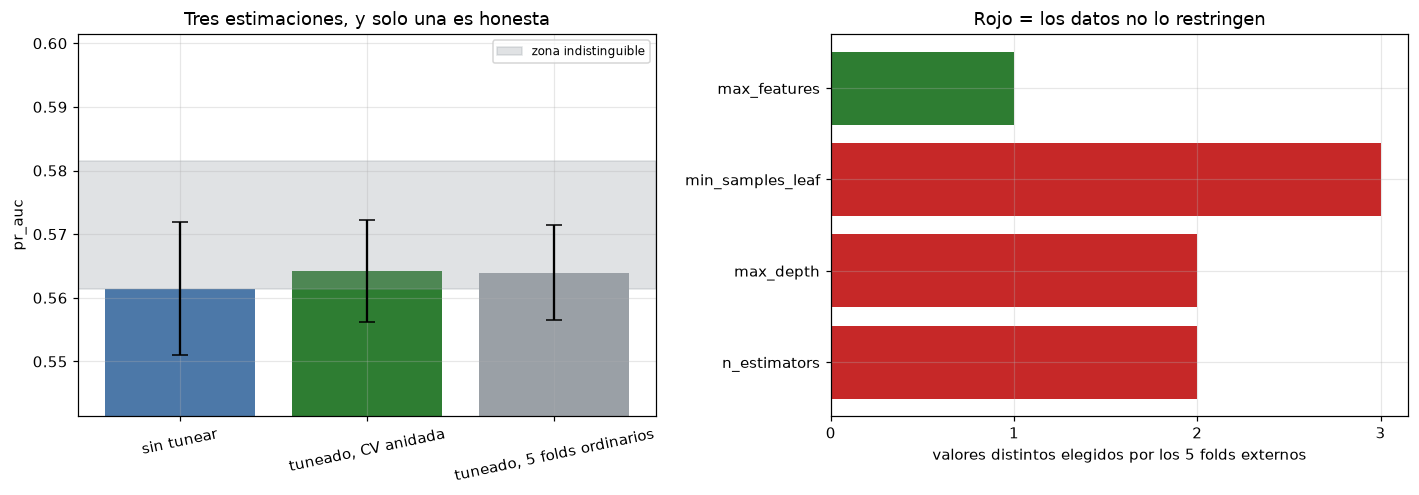

Ganancia del tuning (estimacion honesta): +0.0028   desviacion entre folds 0.0080   umbral 0.02
Sesgo optimista de la estimacion ingenua: -0.0003

 fold  inner_best_pr_auc  n_estimators  max_depth  min_samples_leaf  max_features
    1           0.558316           500          8                 1           0.3
    2           0.566504           500         10                 1           0.3
    3           0.562883           500          8                 6           0.3
    4           0.560634           300          8                 3           0.3
    5           0.561712           500         10                 1           0.3


In [12]:
nested = find_run(runs, "tuning", "tuning-nested-cv")
optimistic = find_run(runs, "tuning", "tuned-random-forest")
untuned = find_run(runs, "imbalance-comparison", "imbalance-no-treatment")

estimates = {
    "sin tunear": untuned.metric(f"{DECISION_METRIC}_mean"),
    "tuneado, CV anidada": nested.metric(f"{DECISION_METRIC}_mean"),
    "tuneado, 5 folds ordinarios": optimistic.metric(f"{DECISION_METRIC}_mean"),
}
errors = {
    "sin tunear": untuned.metric(f"{DECISION_METRIC}_std"),
    "tuneado, CV anidada": nested.metric(f"{DECISION_METRIC}_std"),
    "tuneado, 5 folds ordinarios": optimistic.metric(f"{DECISION_METRIC}_std"),
}
best_params = read_run_artefact(nested.run_id, "per_outer_fold_best_params.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].bar(
    list(estimates),
    list(estimates.values()),
    yerr=list(errors.values()),
    capsize=5,
    color=[PALETTE["reference"], PALETTE["winner"], PALETTE["floor"]],
)
base = estimates["sin tunear"]
axes[0].axhspan(
    base,
    base + PRACTICAL_SIGNIFICANCE_THRESHOLD,
    color=PALETTE["floor"],
    alpha=0.3,
    label="zona indistinguible",
)
axes[0].set_ylim(base - 0.02, base + 0.04)
axes[0].set_ylabel(DECISION_METRIC)
axes[0].set_title("Tres estimaciones, y solo una es honesta")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=12)

tuned_columns = [c for c in best_params.columns if c not in ("fold", "inner_best_pr_auc")]
distinct = [best_params[c].nunique() for c in tuned_columns]
axes[1].barh(
    tuned_columns,
    distinct,
    color=[PALETTE["warn"] if d > 1 else PALETTE["winner"] for d in distinct],
)
axes[1].set_xlabel("valores distintos elegidos por los 5 folds externos")
axes[1].set_title("Rojo = los datos no lo restringen")
axes[1].set_xticks(range(0, max(distinct) + 1))
fig.tight_layout()
plt.show()

gain = estimates["tuneado, CV anidada"] - estimates["sin tunear"]
optimism = estimates["tuneado, 5 folds ordinarios"] - estimates["tuneado, CV anidada"]
print(
    f"Ganancia del tuning (estimacion honesta): {gain:+.4f}   "
    f"desviacion entre folds {errors['tuneado, CV anidada']:.4f}   "
    f"umbral {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f}"
)
print(f"Sesgo optimista de la estimacion ingenua: {optimism:+.4f}\n")
print(best_params.to_string(index=False))

**Interpretación.** La ganancia del tuning cabe dentro de la banda gris: no es distinguible
del ruido de partición, después de cientos de ajustes de modelo.

**El sesgo optimista resultó ser prácticamente nulo, y eso es un hallazgo por derecho
propio.** La CV anidada existe para corregir un sesgo que aquí **no apareció**. La lectura
coherente es que la métrica está en una meseta: si ninguna configuración es apreciablemente
mejor que otra, elegir la mejor de treinta sobre una partición no puede sobreajustarla,
porque no hay nada que sobreajustar. Esto **no** significa que la CV anidada sobrara — sin
ella, el cero no se podría afirmar.

**El panel derecho dice lo mismo desde otro ángulo.** Un hiperparámetro sobre el que cinco
folds no se ponen de acuerdo es un hiperparámetro que los datos no restringen. Solo uno sale
en verde, elegido por los cinco folds y por el estudio final: `max_features`. Es el único
hallazgo accionable del turno de tuning, y es la razón por la que el modelo productivo
adopta los hiperparámetros tuneados pese a que la ganancia no se distinga de cero.

---

# 8 · La calibración: el forest ya estaba calibrado

Todas las métricas de ordenamiento leen solo el *orden* que inducen las puntuaciones. Brier
lee su *valor*. Un modelo puede ordenar perfectamente y decir "38%" sobre un grupo que
incumple al 22%, y sin probabilidad no hay pérdida esperada ni umbral operativo.

El calibrador se ajusta **dentro** de cada fold, y la curva se dibuja con probabilidades
**fuera de fold**: una curva dibujada en muestra se apoya en la diagonal por un motivo que
no tiene nada que ver con estar bien calibrado.

In [13]:
calibration = {
    "sin calibrar": find_run(runs, "calibration", "calibration-uncalibrated"),
    "sigmoide (Platt)": find_run(runs, "calibration", "calibration-sigmoid"),
    "isotonica": find_run(runs, "calibration", "calibration-isotonic"),
}
curves_run = find_run(runs, "calibration", "calibration-curves")
curves = read_run_artefact(curves_run.run_id, "calibration_curves.csv")
comparison_table(calibration, METRIC_NAMES)

,sin calibrar,sigmoide (Platt),isotonica
pr_auc,0.5640 ± 0.0075,0.5640 ± 0.0075,0.5507 ± 0.0078
roc_auc,0.7874 ± 0.0083,0.7874 ± 0.0083,0.7868 ± 0.0076
ks,0.4388 ± 0.0197,0.4388 ± 0.0197,0.4338 ± 0.0170
gini,0.5748 ± 0.0166,0.5748 ± 0.0166,0.5736 ± 0.0152
brier,0.1332 ± 0.0021,0.1340 ± 0.0022,0.1336 ± 0.0019
precision_at_top_10pct,0.7070 ± 0.0177,0.7070 ± 0.0177,0.7055 ± 0.0169
precision_at_top_5pct,0.7713 ± 0.0223,0.7713 ± 0.0223,0.7665 ± 0.0126


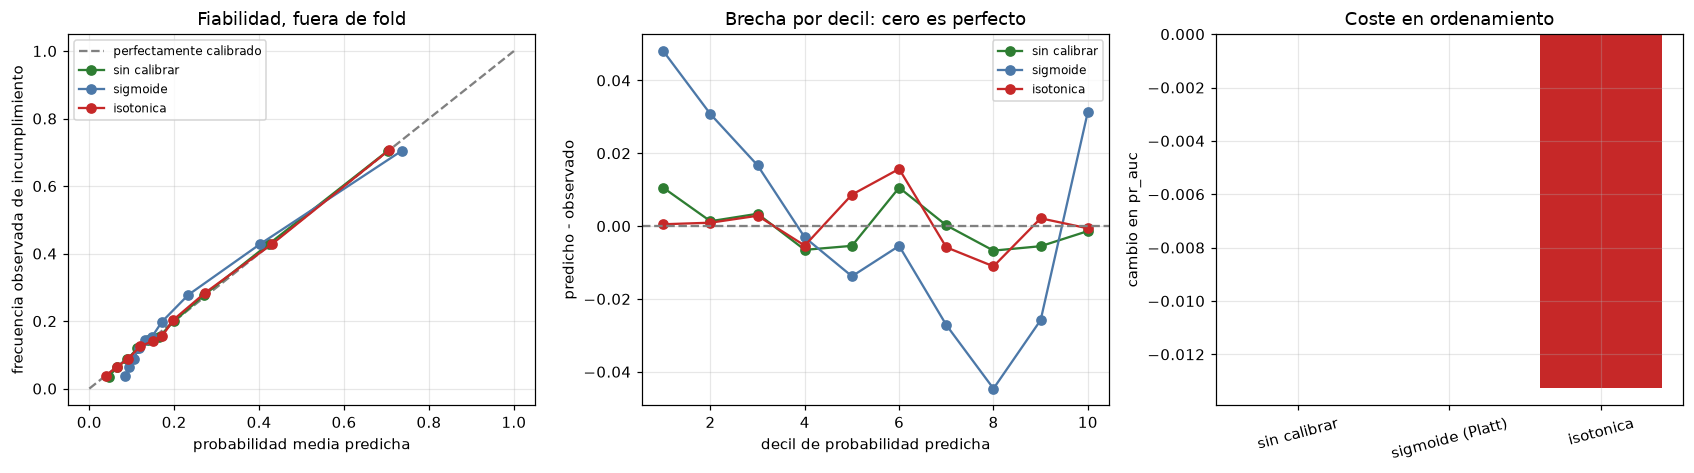

sin calibrar    brier 0.133228   peor brecha en un decil 0.0106   cambio en pr_auc +0.0000
sigmoide        brier 0.134009   peor brecha en un decil 0.0481   cambio en pr_auc +0.0000
isotonica       brier 0.133551   peor brecha en un decil 0.0157   cambio en pr_auc -0.0133


In [14]:
NAMES = {"uncalibrated": "sin calibrar", "sigmoid": "sigmoide", "isotonic": "isotonica"}
COLOURS = {
    "uncalibrated": PALETTE["winner"],
    "sigmoid": PALETTE["reference"],
    "isotonic": PALETTE["warn"],
}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

axes[0].plot([0, 1], [0, 1], ls="--", c="grey", label="perfectamente calibrado")
for arm, group in curves.groupby("arm", sort=False):
    axes[0].plot(
        group["mean_predicted"],
        group["observed_frequency"],
        marker="o",
        color=COLOURS[arm],
        label=NAMES[arm],
    )
axes[0].set_xlabel("probabilidad media predicha")
axes[0].set_ylabel("frecuencia observada de incumplimiento")
axes[0].set_title("Fiabilidad, fuera de fold")
axes[0].legend(fontsize=8)

for arm, group in curves.groupby("arm", sort=False):
    axes[1].plot(group["bin"], group["gap"], marker="o", color=COLOURS[arm], label=NAMES[arm])
axes[1].axhline(0, ls="--", c="grey")
axes[1].set_xlabel("decil de probabilidad predicha")
axes[1].set_ylabel("predicho - observado")
axes[1].set_title("Brecha por decil: cero es perfecto")
axes[1].legend(fontsize=8)

frame = metric_frame(calibration, [DECISION_METRIC, "brier"])
raw = frame.loc["sin calibrar"]
axes[2].bar(
    frame.index,
    frame[DECISION_METRIC] - raw[DECISION_METRIC],
    color=[PALETTE["winner"], PALETTE["reference"], PALETTE["warn"]],
)
axes[2].axhline(0, c="black", lw=1)
axes[2].set_ylabel(f"cambio en {DECISION_METRIC}")
axes[2].set_title("Coste en ordenamiento")
axes[2].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

worst = curves.assign(abs_gap=curves["gap"].abs()).groupby("arm")["abs_gap"].max()
for arm in ["uncalibrated", "sigmoid", "isotonic"]:
    label = NAMES[arm]
    key = "sigmoide (Platt)" if label == "sigmoide" else label
    print(
        f"{label:<16}brier {frame.loc[key, 'brier']:.6f}   "
        f"peor brecha en un decil {worst[arm]:.4f}   "
        f"cambio en {DECISION_METRIC} "
        f"{frame.loc[key, DECISION_METRIC] - raw[DECISION_METRIC]:+.4f}"
    )

**Interpretación.** Las tres curvas se pegan a la diagonal, y la que **menos** se separa es
la del forest **sin calibrar**. Tiene el mejor Brier de los tres y la menor brecha en cada
decil. Hay un mecanismo detrás: cientos de árboles promediando frecuencias de hoja ya
producen una probabilidad, no una proporción de votos. No quedaba mucho que corregir.

**El panel derecho contiene el hallazgo que más cuesta explicar y más enseña.** La
calibración isotónica **bajó el PR-AUC**, y un mapa monótono no puede reordenar nada.

La explicación: la regresión isotónica es **no decreciente**, no *estrictamente* creciente.
Colapsa rangos de puntuación en un valor constante, y eso **crea empates**.
`precision@top-k%` y la precisión media se calculan precisamente sobre esos empates, así que
aplanar el score las degrada sin haber invertido el orden de ningún par. La sigmoide, que sí
es estrictamente creciente, deja las siete métricas de ordenamiento bit-idénticas — y ese
contraste es lo que confirma el mecanismo.

**Por eso la sigmoide se conserva como decisión conservadora y no como mejora** (ADR-0007,
decisión 1): su costo está medido y es despreciable, y es un seguro barato si la
distribución de puntuaciones se desplaza. La decisión de calibrar se tomó **antes** de esta
medición y la evidencia la contradice; queda registrada como tal.

---

# 9 · El umbral operativo: una decisión de negocio, no del modelo

El ADR-0002 descarta F1 como métrica de decisión exactamente por esto: fija un umbral con un
criterio interno del clasificador, y el clasificador no sabe lo que cuesta un error. PR-AUC
evalúa el modelo en **todos** los umbrales precisamente para poder aplazar la elección hasta
donde se conocen los costos.

**El supuesto:** un falso negativo —prestar a quien incumple— cuesta **cinco veces** un falso
positivo —rechazar a quien habría pagado—. Solo importa el cociente.

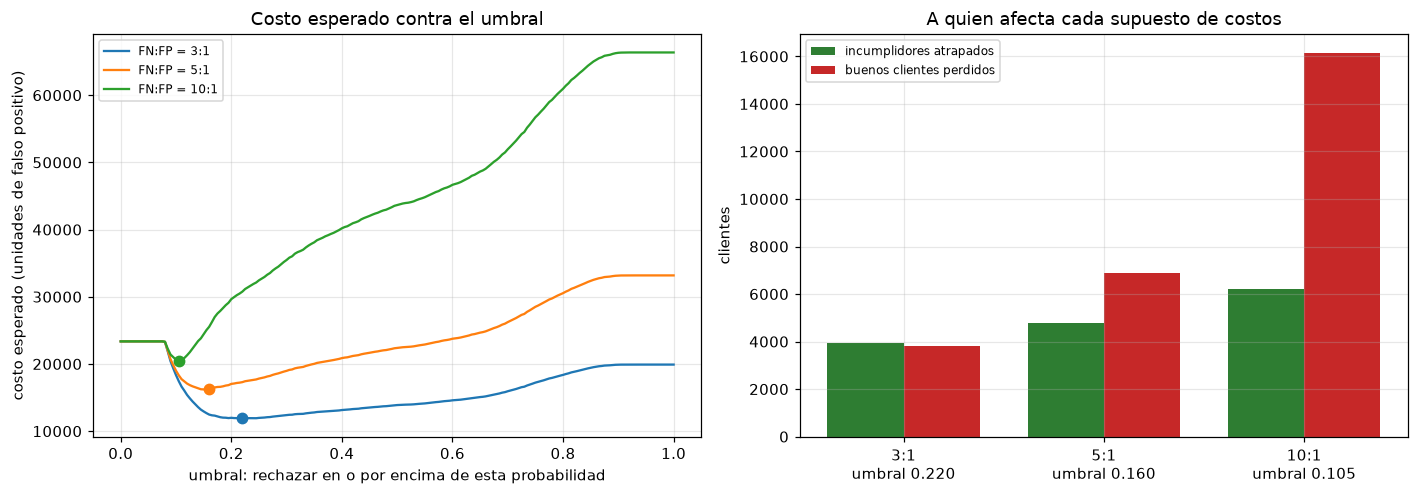

Poblacion puntuada: 30,000 clientes

3:1  umbral 0.220  rechaza  7,768 (25.9%)  atrapa 3,942  pierde  3,826  recall 0.5940  precision 0.5075
5:1  umbral 0.160  rechaza 11,635 (38.8%)  atrapa 4,769  pierde  6,866  recall 0.7187  precision 0.4099
10:1  umbral 0.105  rechaza 22,329 (74.4%)  atrapa 6,200  pierde 16,129  recall 0.9343  precision 0.2777

Entre 3:1 y 10:1 el numero de rechazos se mueve en 14,561 clientes (48.5% del libro)


In [15]:
threshold_run = find_run(runs, "threshold-selection", "threshold-selection")
sweep = read_run_artefact(threshold_run.run_id, "threshold_sweep.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ratio, group in sweep.groupby("cost_ratio"):
    best = group.loc[group["expected_cost"].idxmin()]
    axes[0].plot(group["threshold"], group["expected_cost"], label=f"FN:FP = {ratio:g}:1")
    axes[0].scatter([best["threshold"]], [best["expected_cost"]], zorder=3, s=45)
axes[0].set_xlabel("umbral: rechazar en o por encima de esta probabilidad")
axes[0].set_ylabel("costo esperado (unidades de falso positivo)")
axes[0].set_title("Costo esperado contra el umbral")
axes[0].legend(fontsize=8)

optima = (
    sweep.loc[sweep.groupby("cost_ratio")["expected_cost"].idxmin()]
    .sort_values("cost_ratio")
    .reset_index(drop=True)
)
optima["refused"] = optima["true_positives"] + optima["false_positives"]
total = int(
    optima.loc[0, ["true_positives", "false_positives", "true_negatives", "false_negatives"]].sum()
)

width = 0.38
x = np.arange(len(optima))
axes[1].bar(
    x - width / 2,
    optima["true_positives"],
    width,
    color=PALETTE["winner"],
    label="incumplidores atrapados",
)
axes[1].bar(
    x + width / 2,
    optima["false_positives"],
    width,
    color=PALETTE["warn"],
    label="buenos clientes perdidos",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [
        f"{r:g}:1\numbral {t:.3f}"
        for r, t in zip(optima["cost_ratio"], optima["threshold"], strict=True)
    ]
)
axes[1].set_ylabel("clientes")
axes[1].set_title("A quien afecta cada supuesto de costos")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Poblacion puntuada: {total:,} clientes\n")
for _, row in optima.iterrows():
    refused = int(row["refused"])
    recall = row["true_positives"] / (row["true_positives"] + row["false_negatives"])
    precision = row["true_positives"] / refused
    print(
        f"{row['cost_ratio']:g}:1  umbral {row['threshold']:.3f}  "
        f"rechaza {refused:>6,} ({refused / total:5.1%})  "
        f"atrapa {int(row['true_positives']):>5,}  "
        f"pierde {int(row['false_positives']):>6,}  "
        f"recall {recall:.4f}  precision {precision:.4f}"
    )

span = int(optima["refused"].max() - optima["refused"].min())
print(
    f"\nEntre 3:1 y 10:1 el numero de rechazos se mueve en {span:,} clientes "
    f"({span / total:.1%} del libro)"
)

**Interpretación.** La curva de la izquierda tiene un mínimo poco pronunciado: alrededor del
óptimo, mover el umbral cambia poco el costo. Eso es una buena noticia — la elección exacta
no es frágil **dado el supuesto**.

**El panel derecho es, en mi opinión, la visualización más reveladora de todo el notebook.**
Muestra a cuántas personas afecta cada supuesto de costos, y la respuesta es: a una fracción
enorme del libro. Al pasar de 3:1 a 10:1 las barras rojas —clientes que habrían pagado y son
rechazados— se multiplican.

Pónganse las cifras en perspectiva. **Todo lo ganado por modelado en esta fase** —cambiar de
regresión logística a random forest, quitar el tratamiento de desbalance y tunear— suma unas
pocas centésimas de PR-AUC. **Mover el cociente de costos desplaza a casi la mitad del
libro.** Quien fija ese cociente toma una decisión mucho mayor que la de elegir el modelo.

Y el cociente **no tiene respaldo empírico en este dataset**: no hay datos de exposición, de
recuperación ni de margen. Se declaró, no se midió. Conseguir esos datos tiene más valor
esperado que cualquier mejora adicional del modelo.

---

# 10 · SHAP: qué usa el modelo

Los nombres de las features se verificaron de punta a punta antes de dibujar nada: los que
declara el preprocesador, los que registró el modelo y los que recibió SHAP son la misma
lista en el mismo orden. Un `ColumnTransformer` que pierde sus nombres etiqueta su salida por
posición, y SHAP atribuiría entonces la explicación a la variable que ocupe ese índice — una
historia legible, confiada y falsa sobre por qué se rechazó a un cliente.

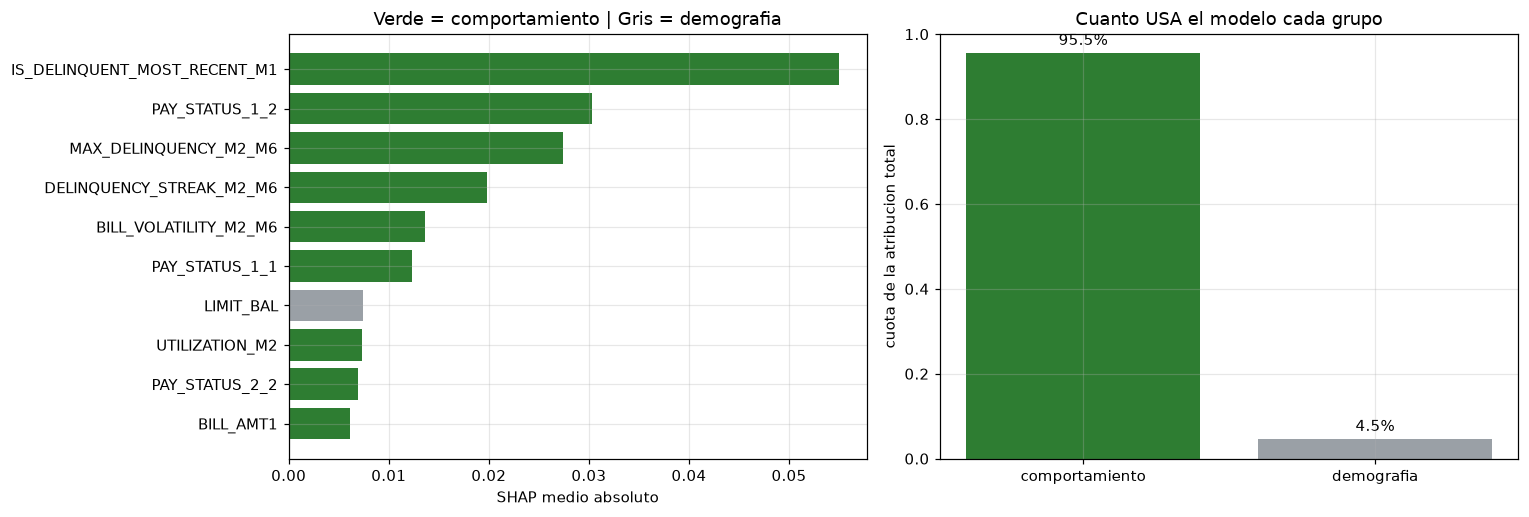

                     feature  mean_abs_shap  mean_shap
IS_DELINQUENT_MOST_RECENT_M1       0.054999  -0.004235
              PAY_STATUS_1_2       0.030297  -0.002732
       MAX_DELINQUENCY_M2_M6       0.027409   0.005148
    DELINQUENCY_STREAK_M2_M6       0.019836  -0.002563
       BILL_VOLATILITY_M2_M6       0.013601  -0.000820
              PAY_STATUS_1_1       0.012327   0.005120
                   LIMIT_BAL       0.007409  -0.000187
              UTILIZATION_M2       0.007325   0.000106
              PAY_STATUS_2_2       0.006902  -0.001142
                   BILL_AMT1       0.006176  -0.000419

Cuota de atribucion: comportamiento 95.5%, demografia 4.5%


In [16]:
shap_run = find_run(runs, "shap-analysis", "shap-analysis")
importance = read_run_artefact(shap_run.run_id, "shap_feature_importance.csv")
top = importance.head(10).iloc[::-1]

DEMOGRAPHIC = {"SEX", "EDUCATION", "MARRIAGE", "AGE", "LIMIT_BAL"}


def is_demographic(feature: str) -> bool:
    """A matrix column is demographic when the source column it came from is."""
    return any(feature == d or feature.startswith(f"{d}_") for d in DEMOGRAPHIC)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].barh(
    top["feature"],
    top["mean_abs_shap"],
    color=[PALETTE["floor"] if is_demographic(f) else PALETTE["winner"] for f in top["feature"]],
)
axes[0].set_xlabel("SHAP medio absoluto")
axes[0].set_title("Verde = comportamiento | Gris = demografia")

shares = {
    "comportamiento": importance.loc[
        ~importance["feature"].map(is_demographic), "mean_abs_shap"
    ].sum(),
    "demografia": importance.loc[importance["feature"].map(is_demographic), "mean_abs_shap"].sum(),
}
total_shap = sum(shares.values())
axes[1].bar(
    list(shares),
    [v / total_shap for v in shares.values()],
    color=[PALETTE["winner"], PALETTE["floor"]],
)
axes[1].set_ylabel("cuota de la atribucion total")
axes[1].set_ylim(0, 1)
axes[1].set_title("Cuanto USA el modelo cada grupo")
for i, v in enumerate(shares.values()):
    axes[1].text(i, v / total_shap + 0.02, f"{v / total_shap:.1%}", ha="center")
fig.tight_layout()
plt.show()

print(importance.head(10).to_string(index=False))
print(
    f"\nCuota de atribucion: comportamiento {shares['comportamiento'] / total_shap:.1%}, "
    f"demografia {shares['demografia'] / total_shap:.1%}"
)

**Interpretación.** Nueve de las diez features más importantes son de comportamiento. Esto
**confirma la hipótesis principal por una vía independiente**: la sección 4 midió cuánto
*vale* cada grupo para la métrica; esto mide cuánto lo *usa* el modelo. Son preguntas
distintas y que coincidan no estaba garantizado.

La importancia está además muy **concentrada**: la primera feature vale varias veces la
décima. El modelo se apoya casi todo en la mora del mes más reciente.

**Una advertencia de lectura que importa más de lo que parece.** La columna `mean_shap` de la
tabla es el efecto **promedio sobre la población**, no el efecto de que la feature esté
presente. `IS_DELINQUENT_MOST_RECENT_M1` tiene media firmada negativa porque la mayoría de
los clientes **no** están en mora, y ese cero mayoritario domina el promedio. **Leer ese signo
como "estar en mora reduce el riesgo" es exactamente al revés.** Para la dirección hay que
mirar el `dependence plot`, no la media.

---

# 11 · Equidad: la disparidad está medida

El modelo consume `SEX`, `EDUCATION`, `MARRIAGE` y `AGE`. Que la demografía pese poco en la
atribución SHAP **no** es prueba de ausencia de sesgo: un peso pequeño sobre una población
grande puede seguir siendo trato desigual.

Definiciones, con `Ŷ=1` = "el modelo recomienda rechazar":

| Nombre | Fórmula | Qué mide |
|---|---|---|
| Paridad demográfica | `P(Ŷ=1 \| A=a)` igual para todo `a` | Si todos los grupos se rechazan igual. **Ignora** si incumplen igual |
| Equidad de oportunidad | `P(Ŷ=1 \| Y=1, A=a)` igual | De los que sí incumplieron, cuántos se atraparon |
| Tasa de falsos positivos | `P(Ŷ=1 \| Y=0, A=a)` | **De los que habrían pagado, cuántos se rechazaron por error** |

**Esta sección mide y no corrige.** Mitigar es una decisión con alternativas y costos.

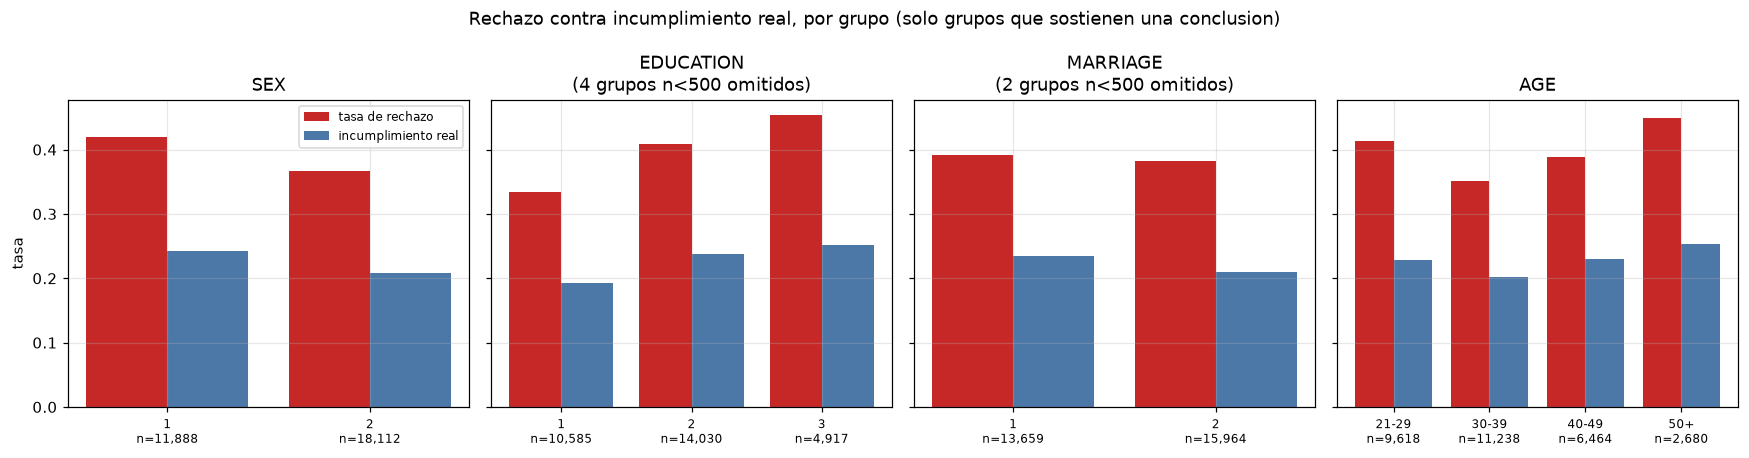

SEX        razon de impacto dispar 0.8759   brecha rechazo 0.0520   brecha tasa base 0.0339
EDUCATION  razon de impacto dispar 0.7364  <- por debajo de 0.80   brecha rechazo 0.1198   brecha tasa base 0.0592
MARRIAGE   razon de impacto dispar 0.9730   brecha rechazo 0.0106   brecha tasa base 0.0254
AGE        razon de impacto dispar 0.7796  <- por debajo de 0.80   brecha rechazo 0.0991   brecha tasa base 0.0505


In [17]:
fairness = find_run(runs, "fairness-analysis", "fairness-analysis")
ATTRIBUTES = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
full = {a: read_run_artefact(fairness.run_id, f"fairness_full_{a}.csv") for a in ATTRIBUTES}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharey=True)
for ax, attribute in zip(axes, ATTRIBUTES, strict=True):
    table = full[attribute]
    usable = table[table["supports_conclusion"]]
    small = table[~table["supports_conclusion"]]
    x = np.arange(len(usable))
    ax.bar(x - 0.2, usable["refusal_rate"], 0.4, color=PALETTE["warn"], label="tasa de rechazo")
    ax.bar(
        x + 0.2,
        usable["base_default_rate"],
        0.4,
        color=PALETTE["reference"],
        label="incumplimiento real",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{g}\nn={int(n):,}" for g, n in zip(usable["group"], usable["n"], strict=True)],
        fontsize=8,
    )
    ax.set_title(f"{attribute}" + (f"\n({len(small)} grupos n<500 omitidos)" if len(small) else ""))
axes[0].set_ylabel("tasa")
axes[0].legend(fontsize=8)
fig.suptitle(
    "Rechazo contra incumplimiento real, por grupo (solo grupos que sostienen una conclusion)"
)
fig.tight_layout()
plt.show()

for attribute in ATTRIBUTES:
    usable = full[attribute][full[attribute]["supports_conclusion"]]
    ratio = usable["refusal_rate"].min() / usable["refusal_rate"].max()
    base_gap = usable["base_default_rate"].max() - usable["base_default_rate"].min()
    print(
        f"{attribute:<11}razon de impacto dispar {ratio:.4f}"
        f"{'  <- por debajo de 0.80' if ratio < 0.8 else ''}   "
        f"brecha rechazo {usable['refusal_rate'].max() - usable['refusal_rate'].min():.4f}   "
        f"brecha tasa base {base_gap:.4f}"
    )

**Interpretación.** Las barras rojas son la tasa de rechazo y las azules el incumplimiento
real. Si un grupo incumple más, rechazarlo más **no** es sesgo. Lo que hay que mirar es si el
rojo crece **más rápido** que el azul, y en dos de los cuatro atributos crece
aproximadamente al doble.

Dos atributos caen por debajo de la razón de impacto dispar que la guía convencional señala.
`MARRIAGE` es la excepción interesante: su brecha de rechazo es **menor** que su brecha de
tasa base.

Los grupos por debajo de 500 filas se omiten de estos máximos: a esos tamaños el error
estándar de una tasa es del mismo orden que las disparidades buscadas. Están en la evidencia
con su tamaño; lo que no pueden es anclar un extremo.

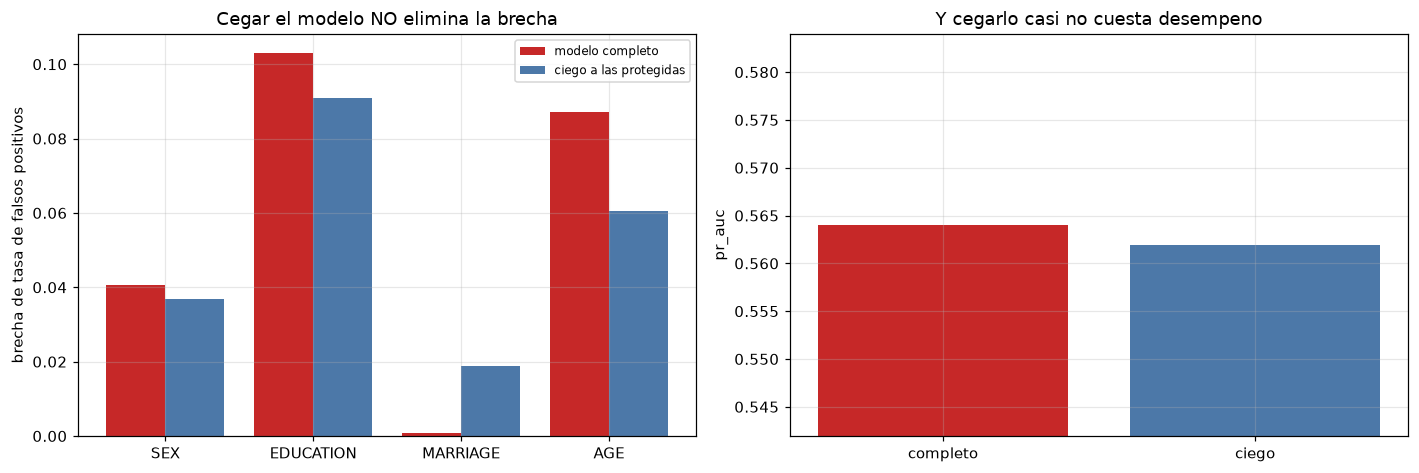

           completo  ciego  reduccion
SEX          0.0406 0.0369    -0.0918
EDUCATION    0.1029 0.0908    -0.1175
MARRIAGE     0.0009 0.0188    19.3758
AGE          0.0871 0.0606    -0.3044

Costo de cegar el modelo en pr_auc: -0.0020   umbral 0.02 -> dentro del ruido


In [18]:
blind = {a: read_run_artefact(fairness.run_id, f"fairness_blind_{a}.csv") for a in ATTRIBUTES}


def fpr_gap(table: pd.DataFrame) -> float:
    """Largest false-positive-rate gap among groups that clear the size floor."""
    usable = table[table["supports_conclusion"]]
    return float(usable["false_positive_rate"].max() - usable["false_positive_rate"].min())


gaps = pd.DataFrame(
    {
        "completo": {a: fpr_gap(full[a]) for a in ATTRIBUTES},
        "ciego": {a: fpr_gap(blind[a]) for a in ATTRIBUTES},
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(ATTRIBUTES))
axes[0].bar(x - 0.2, gaps["completo"], 0.4, color=PALETTE["warn"], label="modelo completo")
axes[0].bar(x + 0.2, gaps["ciego"], 0.4, color=PALETTE["reference"], label="ciego a las protegidas")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ATTRIBUTES)
axes[0].set_ylabel("brecha de tasa de falsos positivos")
axes[0].set_title("Cegar el modelo NO elimina la brecha")
axes[0].legend(fontsize=8)

perf = {
    "completo": fairness.metric("full_model_pr_auc"),
    "ciego": fairness.metric("blind_model_pr_auc"),
}
axes[1].bar(list(perf), list(perf.values()), color=[PALETTE["warn"], PALETTE["reference"]])
axes[1].set_ylim(min(perf.values()) - 0.02, max(perf.values()) + 0.02)
axes[1].set_ylabel(DECISION_METRIC)
axes[1].set_title("Y cegarlo casi no cuesta desempeno")
fig.tight_layout()
plt.show()

print(
    gaps.assign(reduccion=lambda d: (d["ciego"] - d["completo"]) / d["completo"]).to_string(
        float_format=lambda v: f"{v:.4f}"
    )
)
print(
    f"\nCosto de cegar el modelo en {DECISION_METRIC}: "
    f"{fairness.metric('blindness_cost_pr_auc'):+.4f}   "
    f"umbral {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f} -> dentro del ruido"
)

**Interpretación.** Este par de paneles contiene el hallazgo menos obvio de toda la fase.

Quitarle al modelo las cuatro variables protegidas **casi no cuesta desempeño**: la
diferencia cae dentro del ruido. Y sin embargo **la mayor parte de la brecha sobrevive**. En
un atributo incluso **empeora**.

El motivo: las features de comportamiento están **correlacionadas** con las demográficas.
Borrar la etiqueta no borra la información — el modelo la reconstruye por proxies. **La
equidad por omisión no funciona aquí**, y presentar el modelo como equitativo porque "no mira
el sexo" sería falso y está medido que lo sería.

Este proyecto **cuantificó** la disparidad y **no la mitigó**. Desplegar el modelo es aceptar
estas cifras, no ignorarlas.

---

# 12 · Conclusiones

## Qué va a producción

In [19]:
production = find_run(runs, "production-candidate", "production-model")
trivial_floor = production.metric("cv_baseline_trivial_pr_auc")
logistic_ref = production.metric("cv_baseline_logistic_pr_auc")
final = production.metric("cv_pr_auc_mean")

print(f"Modelo     : random forest {dict(PRODUCTION_FOREST_PARAMS)}")
print(f"             class_weight=None, calibracion {PRODUCTION_CALIBRATION_METHOD}")
print(f"Registrado : {production.tags.get('mlflow.runName')}  run {production.run_id}")
print(f"Umbral     : {PRODUCTION_OPERATING_THRESHOLD:.3f} bajo un supuesto de costos 5:1\n")
print(f"{DECISION_METRIC:<28}{'valor':>10}{'contra el piso':>18}")
print(f"{'piso trivial':<28}{trivial_floor:>10.4f}{'—':>18}")
print(
    f"{'referencia: logistica L2':<28}{logistic_ref:>10.4f}{logistic_ref - trivial_floor:>+18.4f}"
)
print(f"{'modelo productivo':<28}{final:>10.4f}{final - trivial_floor:>+18.4f}")
print(
    f"\nVentaja sobre la logistica: {final - logistic_ref:+.4f}   "
    f"umbral {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f}"
)

Modelo     : random forest {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 18, 'max_features': 0.3}
             class_weight=None, calibracion sigmoid
Registrado : production-model  run 418c633718074bae9473e9ddbbef26d6
Umbral     : 0.160 bajo un supuesto de costos 5:1

pr_auc                           valor    contra el piso
piso trivial                    0.2212                 —
referencia: logistica L2        0.5402           +0.3190
modelo productivo               0.5642           +0.3430

Ventaja sobre la logistica: +0.0241   umbral 0.02


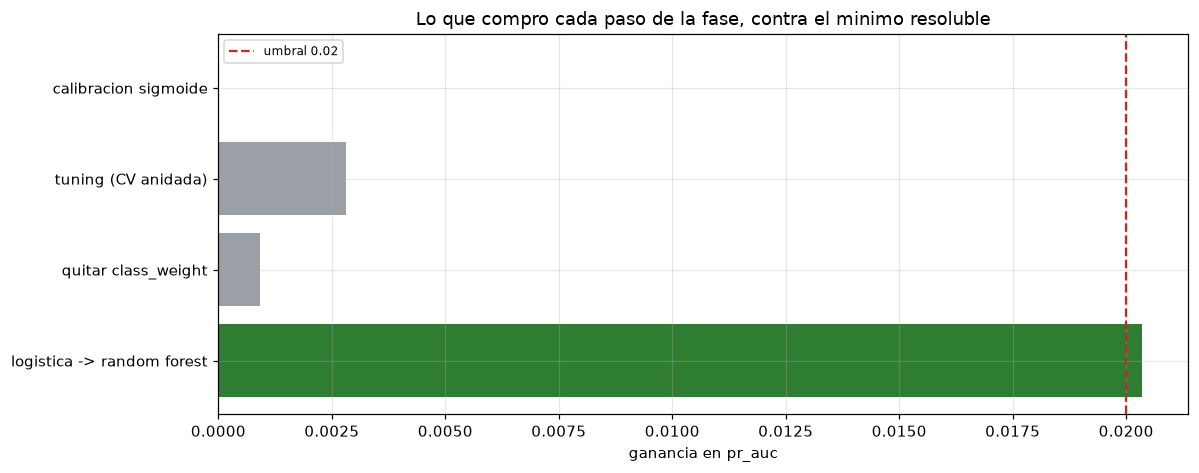

logistica -> random forest    +0.0203   supera el umbral
quitar class_weight           +0.0009   dentro del ruido
tuning (CV anidada)           +0.0028   dentro del ruido
calibracion sigmoide          +0.0000   dentro del ruido

Suma de los pasos: +0.0241


In [20]:
# The whole phase as one picture: what each step bought, against the resolution floor.
def pr(run_type: str, name: str) -> float:
    """Recorded mean of the decision metric for one run."""
    return find_run(runs, run_type, name).metric(f"{DECISION_METRIC}_mean")


steps = {
    "logistica -> random forest": pr("model-comparison", "random-forest")
    - pr("model-comparison", "logistic-l2-balanced"),
    "quitar class_weight": pr("imbalance-comparison", "imbalance-no-treatment")
    - pr("imbalance-comparison", "imbalance-class-weight-balanced"),
    "tuning (CV anidada)": pr("tuning", "tuning-nested-cv")
    - pr("imbalance-comparison", "imbalance-no-treatment"),
    "calibracion sigmoide": pr("calibration", "calibration-sigmoid")
    - pr("calibration", "calibration-uncalibrated"),
}

fig, ax = plt.subplots(figsize=(11, 4.4))
labels = list(steps)
values = [steps[k] for k in labels]
ax.barh(
    labels,
    values,
    color=[
        PALETTE["winner"] if abs(v) >= PRACTICAL_SIGNIFICANCE_THRESHOLD else PALETTE["floor"]
        for v in values
    ],
)
ax.axvline(
    PRACTICAL_SIGNIFICANCE_THRESHOLD,
    ls="--",
    c=PALETTE["warn"],
    label=f"umbral {PRACTICAL_SIGNIFICANCE_THRESHOLD:.2f}",
)
ax.axvline(0, c="black", lw=1)
ax.set_xlabel(f"ganancia en {DECISION_METRIC}")
ax.set_title("Lo que compro cada paso de la fase, contra el minimo resoluble")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for label, value in steps.items():
    resolved = abs(value) >= PRACTICAL_SIGNIFICANCE_THRESHOLD
    mark = "supera el umbral" if resolved else "dentro del ruido"
    print(f"{label:<30}{value:+.4f}   {mark}")
print(f"\nSuma de los pasos: {sum(values):+.4f}")

**Interpretación.** Una sola barra alcanza la línea roja, y la roza. Todo lo demás que se
hizo en esta fase —quitar el tratamiento de desbalance, tunear con cientos de ajustes,
calibrar— cae dentro del ruido de partición.

**El modelo simple casi gana, y eso es un resultado.** La regresión logística está a unas
pocas centésimas de PR-AUC del mejor conjunto encontrado, con coeficientes legibles y un
ajuste de segundos. Lo que el random forest compra sin ambigüedad no es ordenamiento sino
**calibración**, y eso sí importa para el uso declarado: sin probabilidad no hay pérdida
esperada.

## Limitaciones que viajan con el modelo

1. **No hay validación fuera de tiempo.** El dataset no tiene fecha de originación (ADR-0001),
   así que la validación es `StratifiedKFold` y no un corte cronológico. Las métricas estiman
   el desempeño sobre la misma población y el mismo periodo. **Un despliegue real la
   exigiría.**
2. **Disparidad medida y no mitigada.** Sección 11.
3. **El umbral depende de un supuesto de costos sin respaldo empírico.** Sección 9.
4. **Población muy concreta:** Taiwán, 2005, anterior a la crisis de 2008. El modelo no ha
   visto un ciclo adverso.
5. **Códigos no documentados por la fuente** en `PAY_STATUS_*` y `EDUCATION` (ADR-0004). La
   feature más importante del modelo se construye sobre esa escala.
6. **Las predicciones no son reproducibles bit a bit** por la acumulación paralela de votos.
   Irrelevante para una decisión, letal para un test que exija igualdad de bits.

## Qué queda abierto

- Medir el cociente de costos con datos de exposición y recuperación. **Es lo de mayor valor
  esperado de esta lista.**
- Decidir si se mitiga la disparidad, y con qué método.
- Equidad interseccional y calibración por grupo, ninguna de las dos medida.
- La firma del modelo declara enteros; una petición con un nulo rompería el enforcement de
  esquema. Trabajo de la fase de API.